In [75]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd


def load(file):
    return pd.read_csv(file, delimiter=",")


# standardization
def standardize(data, cols_to_drop=None):
    
    if cols_to_drop is None:
        cols_to_drop = []

    cols_to_standardize = data.columns.difference(cols_to_drop)

    data[cols_to_standardize] = (data[cols_to_standardize] - data[cols_to_standardize].mean()) / data[cols_to_standardize].std()


# train-test split
def train_testSplit(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)
    return X_train, X_test, y_train, y_test



In [90]:
# fit
def fit(X_tr, y_tr, epochs=500):

    n_features = X_tr.shape[1]
    n_samples = X_tr.shape[0]


    # -----------------------------
    # w-map using gradient descent:
    # -----------------------------

    #adding new dimension to w and each x from X (absorb the offset): w becomes vec[w0, w] and each x becomes vec[1, x]
    w = np.zeros(n_features + 1)
    X_train = X_tr.copy()
    y_train = y_tr.copy()
    X_train = np.c_[np.ones(n_samples), X_train]

    # Joint likelihood of the data is: 
    #
    #            MUL( sigmoid( yi * xiT @ w) )
    #
    #    Taking log, becomes
    #            SUM( ln( sigmoid( yi * xiT @ w) ) )
    #
    #    With L2 regularization, becomes
    #            obj function        SUM( ln( sigmoid( yi * xiT @ w) ) )  -  lambda/2 * w @ wT
    #
    # We maximize this to get w-map

    
    # objective fucntion
    def obj(w):
        m = y_train * (X_train @ w)
        J = np.sum(np.log(1 / (1 + np.exp(-m)))) - (lam / 2) * (w @ w)

        return J


    # Gradient of the obj function is
    #
    #            SUM ( ( 1 - sigmoid( yi * xiT @ w) ) * yi * xi )  -  lambda * w
    #
    # Now perform gradient descent


    lam = 0.001    # L2 parameter
    eta = 0.002     # learning rate for gradient descent
    tol = 1e-4     # stop if abs(obj(wi) - obj(wi+1)) < tol

    
    # gradient descent
    for i in range(epochs):
        w_prev = w.copy()

        m = y_train * (X_train @ w)
        s = 1 / (1 + np.exp(-m))

        grad = X_train.T @ (y_train * (1 - s))
        grad -= lam * w

        
        w += eta*grad

        obj_val = obj(w)
        obj_prev_val = obj(w_prev)

        print("Epoch ", i, " -- obj: ", obj_val)
        
        if abs(obj_val - obj_prev_val) < tol:
            print("converged")
            break;


    return w
  

In [68]:
# predict
def predict(X_ts, w):

    n_samples = X_ts.shape[0]
    pred_labels = np.zeros(n_samples)

    X_test = X_ts.copy()
    X_test = np.c_[np.ones(n_samples), X_test]

    for i in range(n_samples):
        m = X_test[i].T @ w
        
        prob = 1/(1 + np.exp(-m))
        
        if prob>=0.5:
            pred_labels[i] = 1
        else:
            pred_labels[i] = -1

    return pred_labels
        


In [76]:
# preprocess
X = load("breast-cancer.csv")
X = X.drop(columns=['id'])

X['diagnosis'] = X['diagnosis'].map({'M': 1, 'B': -1})
y = X['diagnosis']
X = X.drop(columns=['diagnosis'])

# train-test split
X_train, X_test, y_train, y_test = train_testSplit(X, y)

# standardization
standardize(X_train)
standardize(X_test)


In [91]:
w = fit(X_train, y_train)

Epoch  0  -- obj:  -79.7202521899344
Epoch  1  -- obj:  -67.43092135674915
Epoch  2  -- obj:  -60.25254960010321
Epoch  3  -- obj:  -56.03228561552611
Epoch  4  -- obj:  -53.35086088072885
Epoch  5  -- obj:  -51.35010816094116
Epoch  6  -- obj:  -49.72181481812091
Epoch  7  -- obj:  -48.34322556409216
Epoch  8  -- obj:  -47.15004295774428
Epoch  9  -- obj:  -46.101959737276935
Epoch  10  -- obj:  -45.17101451154321
Epoch  11  -- obj:  -44.336636258631984
Epoch  12  -- obj:  -43.5831202558797
Epoch  13  -- obj:  -42.898166803972295
Epoch  14  -- obj:  -42.271957537629206
Epoch  15  -- obj:  -41.696535283245076
Epoch  16  -- obj:  -41.1653696635089
Epoch  17  -- obj:  -40.67304319481098
Epoch  18  -- obj:  -40.215018976237765
Epoch  19  -- obj:  -39.78746545017314
Epoch  20  -- obj:  -39.38712210760878
Epoch  21  -- obj:  -39.01119517517309
Epoch  22  -- obj:  -38.657275632864284
Epoch  23  -- obj:  -38.323274107114145
Epoch  24  -- obj:  -38.00736867889749
Epoch  25  -- obj:  -37.707962

In [92]:
pred = predict(X_test, w)

accuracy = np.mean(pred == y_test)
print(accuracy)

0.9824561403508771


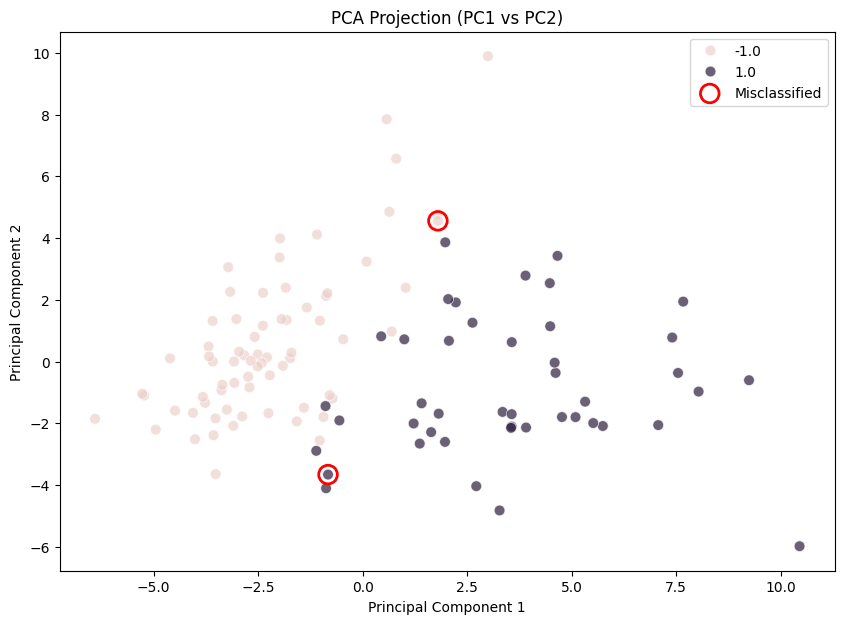

In [93]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

# Find misclassified points
misclassified = pred != y_test

# Build dataframe
df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Predicted": pred,
    "Misclassified": misclassified
})

plt.figure(figsize=(10, 7))

# Plot all points colored by predicted class
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Predicted",
    alpha=0.7,
    s=60
)

# Overlay misclassified points
plt.scatter(
    df.loc[misclassified, "PC1"],
    df.loc[misclassified, "PC2"],
    s=180,
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    label='Misclassified'
)

plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()